# EDA

In [22]:
import pandas as pd
import os

import sys
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())

df_train = pd.read_csv('data/train/train.csv')
df_val = pd.read_csv('data/train/val.csv')
df_holdout = pd.read_csv('data/input/holdout.csv')

display(df_train.head())

,ID,REGION,BRANCH,CITY,subject,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,KINDERGARTENS,BANKS,MK_ON_MM,ROUTES_CNT,CROSSWALK,CROSSROAD,DENSITY_FAMILY_TYPE,COLLEGES,huff_hotel,TRADING_PATCH_SCORE,RENT_HEX,IN_COAL_CITY,IN_OIL_CITY,CITY_TYPE,ON_DUPLICATE_ROAD,HUFF_RANK_COMPS_CANNIBALS,TOTAL_RANK_COMPS_CANNIBALS,INSIDE_YARD,ON_INSIDE_DISTRICT_ROAD,ON_MAIN_CITY_ROAD,ON_INTERCITY_HIGHWAY,ENTRANCE_TO_DISTRICT,ON_DISTRICT_BOTTOM,HUB,ALCOHOL,TOBACCO,LOCATION_MARKET,STATIONS,TRC,METRO,LOCATION_PARK,MINI_TRC,TRADING_PATCH,ENTIRE_DAY,MORNING_ROADSIDE,SEA,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2
0,1,Южный округ,Армавир,Кропоткин,Краснодарский край,2,0.445648,0.019780,0.83,0,0,0,0,5,1,0,1,0,0.000000,0.037696,0.100911,0,0,2,0,2,2,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,0.550733,0,318,0,0,175198.181280689,174259.925193
1,2,Южный округ,Новороссийск Запад,Анапа,Краснодарский край,2,0.780890,0.060494,0.83,0,0,0,0,0,1,0,3,0,0.063891,0.031414,0.229610,0,0,2,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,1.114666,0,317,0,0,360629.424460479,296286.063051
2,3,Южный округ,Ростов-на-Дону Запад,Таганрог,Ростовская область,2,0.471618,0.033680,0.84,0,0,0,1,0,1,0,1,0,0.000000,0.116230,0.128164,0,0,1,0,2,3,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,2,3.730973,10,315,0,0,252109.534031112,250903.579740
3,4,Кавказский округ,Волгоград Восток,Камышин,Волгоградская область,2,0.555293,0.062644,0.76,0,1,0,0,0,1,0,2,0,0.000000,0.045026,0.105460,0,0,2,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,3,1.039118,15,314,0,0,362653.018943467,351612.980992
4,5,Южный округ,Волгодонск,Волгодонск,Ростовская область,2,0.622970,0.030358,0.93,1,0,1,0,0,1,0,3,0,0.000000,0.141361,0.112611,0,0,2,0,7,4,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,2,1.595111,0,314,0,0,295733.315192993,287970.899275


In [23]:
print('Пропуски в тренировочных данных:')
display(df_train.isna().sum())

Пропуски в тренировочных данных:


ID                            0
REGION                        0
BRANCH                        0
CITY                          0
subject                       0
SUBFRMT                       0
TRADE_SQUARE                  0
HuffFamilies                  0
HuffRelativeFamilies          0
HOSPITAL                      0
KINDERGARTENS                 0
BANKS                         0
MK_ON_MM                      0
ROUTES_CNT                    0
CROSSWALK                     0
CROSSROAD                     0
DENSITY_FAMILY_TYPE           0
COLLEGES                      0
huff_hotel                    0
TRADING_PATCH_SCORE           0
RENT_HEX                      0
IN_COAL_CITY                  0
IN_OIL_CITY                   0
CITY_TYPE                     0
ON_DUPLICATE_ROAD             0
HUFF_RANK_COMPS_CANNIBALS     0
TOTAL_RANK_COMPS_CANNIBALS    0
INSIDE_YARD                   0
ON_INSIDE_DISTRICT_ROAD       0
ON_MAIN_CITY_ROAD             0
ON_INTERCITY_HIGHWAY          0
ENTRANCE

In [24]:
print(f'В тренировочных данных {df_train.duplicated().sum()} дубликатов ({round(df_train.duplicated().sum()*100/df_train.shape[0])}%).')


В тренировочных данных 0 дубликатов (0%).


In [25]:
# исправляем столбцы таргетов
df_train['target_1'] = pd.to_numeric(df_train['target_1'], errors='coerce')
df_val['target_1'] = pd.to_numeric(df_val['target_1'], errors='coerce')

df_train = df_train.rename(columns={' target_2 ': 'target_2'})
df_val = df_val.rename(columns={' target_2 ': 'target_2'})

In [26]:
pd.set_option('display.max_columns', None)
df_train.describe()

,ID,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,KINDERGARTENS,BANKS,MK_ON_MM,ROUTES_CNT,CROSSWALK,CROSSROAD,DENSITY_FAMILY_TYPE,COLLEGES,huff_hotel,TRADING_PATCH_SCORE,RENT_HEX,IN_COAL_CITY,IN_OIL_CITY,CITY_TYPE,ON_DUPLICATE_ROAD,HUFF_RANK_COMPS_CANNIBALS,TOTAL_RANK_COMPS_CANNIBALS,INSIDE_YARD,ON_INSIDE_DISTRICT_ROAD,ON_MAIN_CITY_ROAD,ON_INTERCITY_HIGHWAY,ENTRANCE_TO_DISTRICT,ON_DISTRICT_BOTTOM,HUB,ALCOHOL,TOBACCO,LOCATION_MARKET,STATIONS,TRC,METRO,LOCATION_PARK,MINI_TRC,TRADING_PATCH,ENTIRE_DAY,MORNING_ROADSIDE,SEA,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2
count,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15109.000000,15107.000000,15109.000000
mean,7555.000000,1.595341,0.617922,0.039902,0.812911,0.137468,0.373089,0.040042,0.257198,1.449600,0.471242,0.137799,1.915084,0.083063,0.000726,0.052137,0.154851,0.012244,0.031571,1.762923,0.013237,3.948772,3.849030,0.057184,0.189026,0.733867,0.019922,0.015421,0.060692,0.003442,0.011715,0.037196,0.023893,0.018003,0.009597,0.001721,0.011318,0.017473,0.039844,0.085711,0.162817,0.013634,0.997683,0.005162,2.716527,5.287504,10.677345,125.544047,0.033027,0.023231,266904.323259,263793.481161
std,4361.736944,0.490842,0.182940,0.029691,0.189255,0.344352,0.625124,0.208817,0.437104,4.174881,0.499189,0.344700,0.886908,0.275987,0.016011,0.065966,0.100490,0.109978,0.174860,0.791669,0.114293,3.580390,3.457567,0.232202,0.391543,0.441949,0.139737,0.123225,0.238773,0.058567,0.107603,0.189249,0.152721,0.132965,0.097496,0.041449,0.105785,0.131030,0.195599,0.279945,0.369211,0.115971,0.073185,0.071667,0.597790,48.735881,10.759539,59.288227,0.178712,0.150642,83858.550714,84081.877586
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000,37.000000,0.000000,0.000000,109333.196540,100057.205742
25%,3778.000000,1.000000,0.481309,0.022355,0.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.011518,0.093898,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.679969,5.000000,80.000000,0.000000,0.000000,208195.716667,204749.192651
50%,7555.000000,2.000000,0.609735,0.034849,0.880000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.031414,0.126273,0.000000,0.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,2.318281,10.000000,115.000000,0.000000,0.000000,247124.692844,244115.709531
75%,11332.000000,2.000000,0.743808,0.050678,0.940000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.065969,0.178665,0.000000,0.000000,2.000000,0.000000,5.000000,5.000000,0.000000,0.000000,1.

In [27]:
df_train.describe(include=[object])

,REGION,BRANCH,CITY,subject
count,15109,15109,15109,15109
unique,12,97,2763,66
top,Южный округ,Ноябрьск,Москва,Краснодарский край
freq,1818,238,324,1059


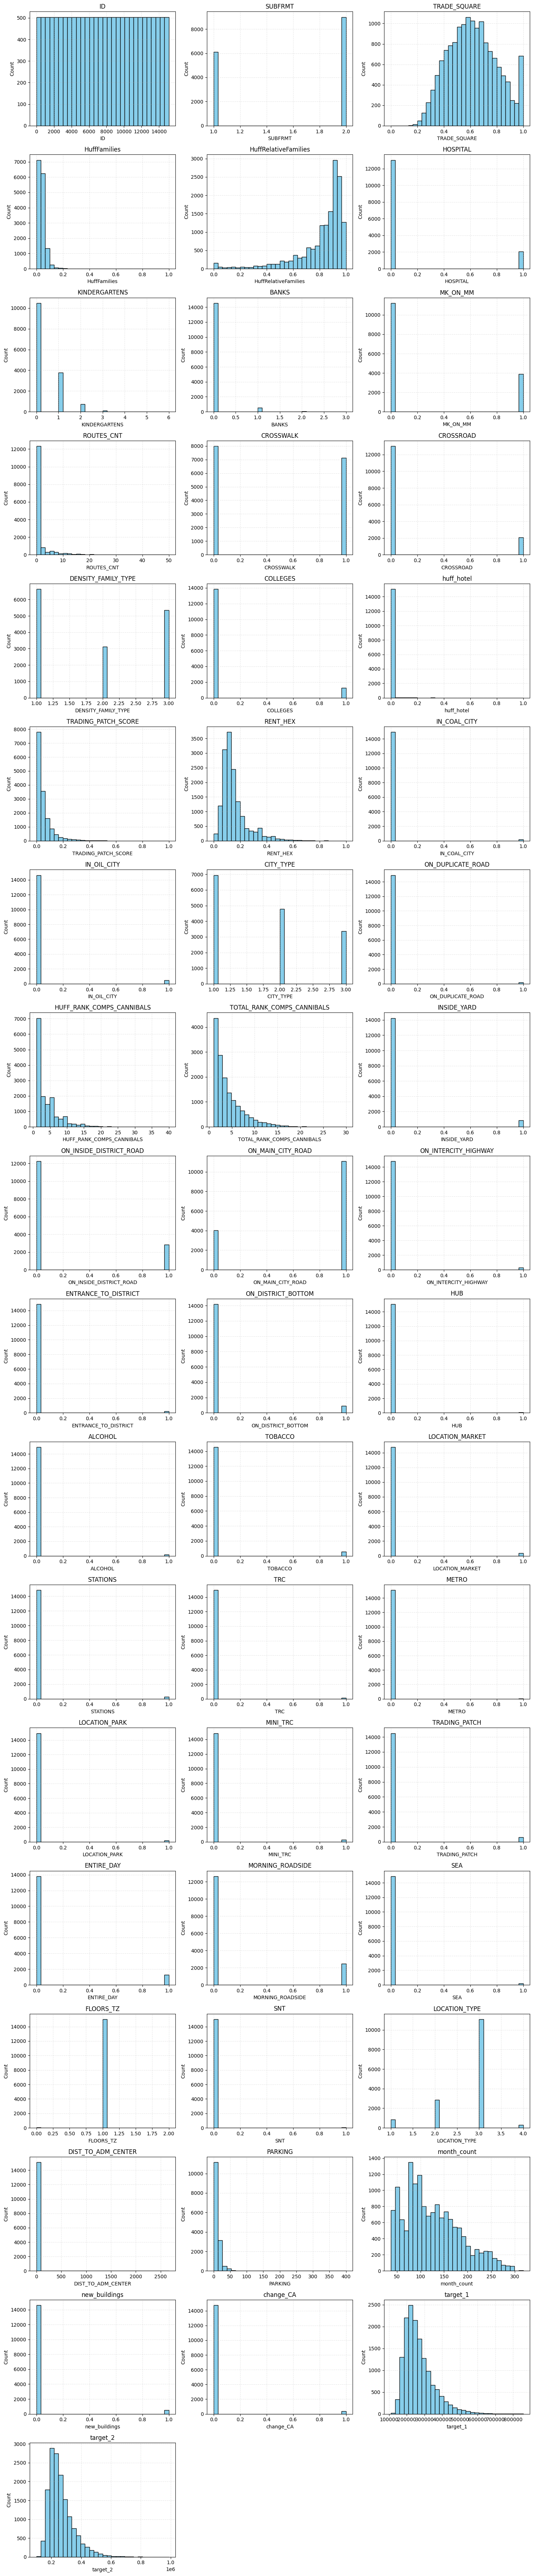

In [28]:
import matplotlib.pyplot as plt

# Выбираем только числовые колонки
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Настройка размера сетки для графиков
n_cols = 3  # количество графиков в ряд
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_train[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
categorical = ['REGION', 'BRANCH', 'CITY', 'subject', 'SUBFRMT', 'HOSPITAL',
               'KINDERGARTENS', 'BANKS', 'MK_ON_MM', 'CROSSWALK',
               'CROSSROAD', 'DENSITY_FAMILY_TYPE', 'COLLEGES',
               'IN_COAL_CITY', 'IN_OIL_CITY', 'CITY_TYPE', 'ON_DUPLICATE_ROAD',
               'INSIDE_YARD', 'ON_INSIDE_DISTRICT_ROAD', 'ON_MAIN_CITY_ROAD',
               'ON_INTERCITY_HIGHWAY', 'ENTRANCE_TO_DISTRICT', 'ON_DISTRICT_BOTTOM',
               'HUB', 'ALCOHOL', 'TOBACCO', 'LOCATION_MARKET', 'STATIONS', 'TRC',
               'METRO', 'LOCATION_PARK', 'MINI_TRC', 'TRADING_PATCH', 'ENTIRE_DAY',
               'MORNING_ROADSIDE', 'SEA', 'FLOORS_TZ', 'SNT', 'LOCATION_TYPE',
               'new_buildings', 'change_CA']

numeric = ['TRADE_SQUARE', 'HuffFamilies', 'HuffRelativeFamilies',
           'ROUTES_CNT', 'huff_hotel', 'TRADING_PATCH_SCORE', 'RENT_HEX',
           'HUFF_RANK_COMPS_CANNIBALS', 'TOTAL_RANK_COMPS_CANNIBALS', 'DIST_TO_ADM_CENTER',
           'PARKING', 'month_count']

target = ['target_1', 'target_2']

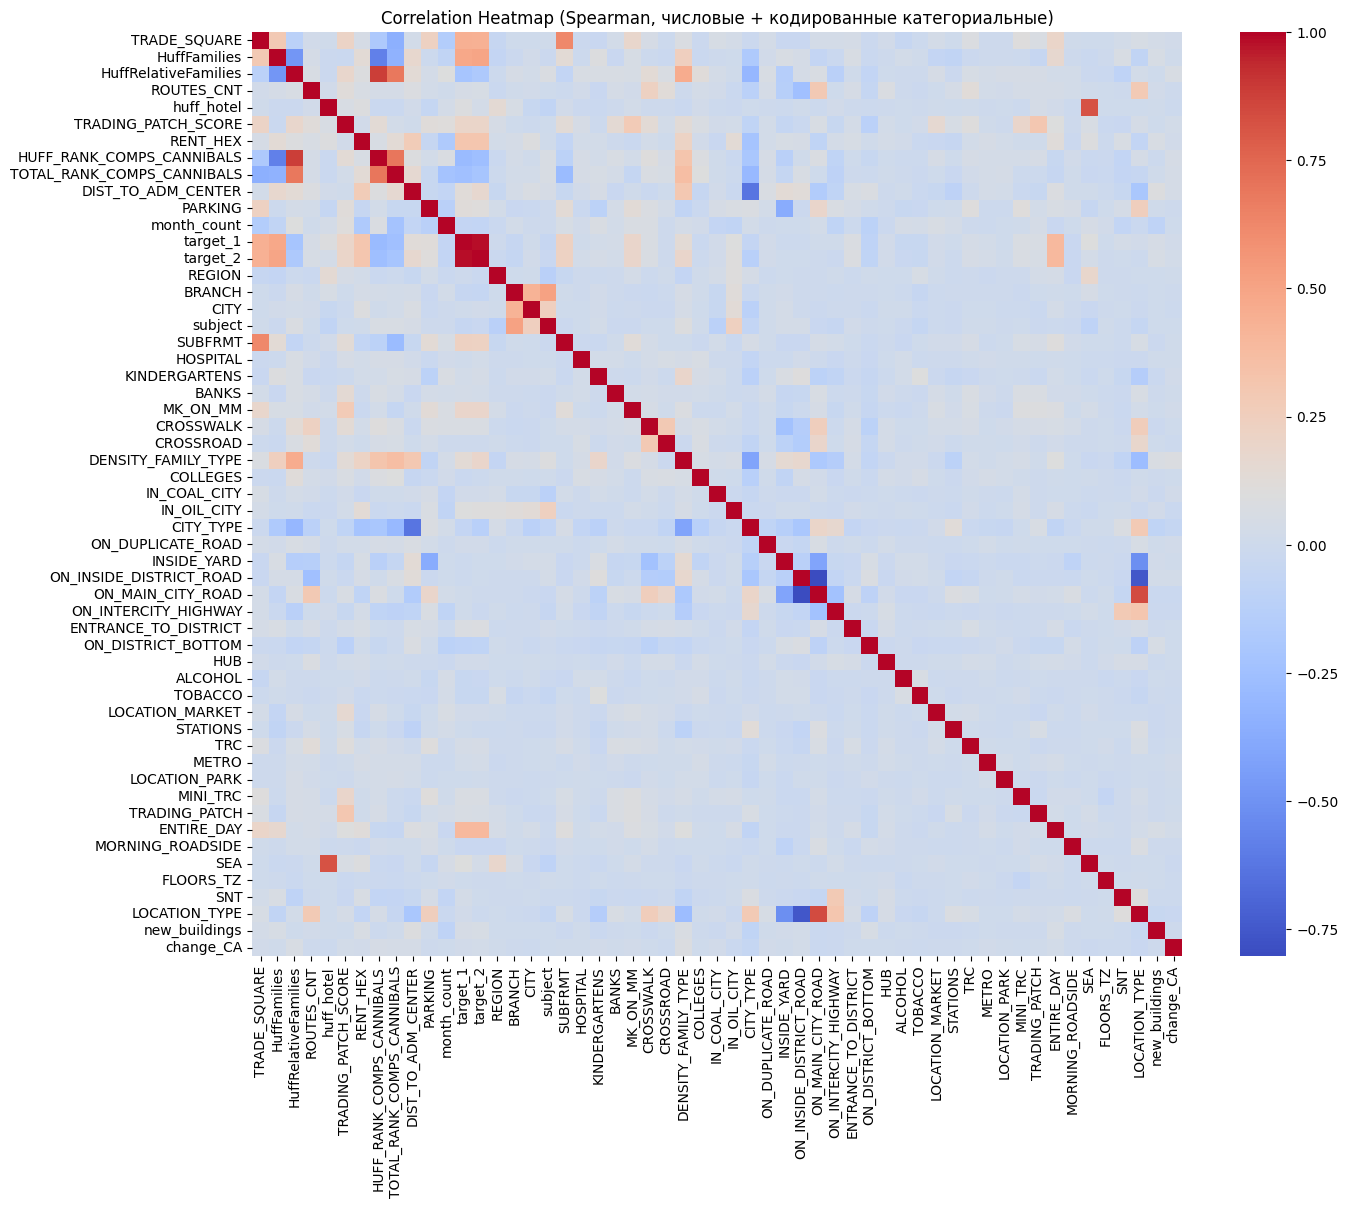

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df_numeric = df_train[numeric + target].apply(pd.to_numeric, errors='coerce')
df_categorical = df_train[categorical].apply(lambda x: x.astype('category').cat.codes)

df_mixed = pd.concat([df_numeric, df_categorical], axis=1)
corr_matrix = df_mixed.corr(method='spearman')
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap (Spearman, числовые + кодированные категориальные)')
plt.show()

In [31]:
df_numeric = df_train[numeric + target].apply(pd.to_numeric, errors='coerce')
df_categorical = df_train[categorical].apply(
    lambda x: x.astype('category').cat.codes
)
df_mixed = pd.concat([df_numeric, df_categorical], axis=1)
corr_matrix = df_mixed.corr(method='spearman')
corr_with_target_num = corr_matrix.loc[numeric, target]
corr_with_target_cat = corr_matrix.loc[categorical, target]
for target_col in target:
    corr_target = corr_with_target_num[target_col].dropna()
    sorted_corr = corr_target.abs().sort_values(ascending=False)

    print(f"\nКорреляции числовых признаков с {target_col} (по убыванию):")
    display(pd.DataFrame({
        'feature': sorted_corr.index,
        'correlation': corr_target[sorted_corr.index].values
    }))

for target_col in target:
    corr_target = corr_with_target_cat[target_col].dropna()
    sorted_corr = corr_target.abs().sort_values(ascending=False)

    print(f"\nКорреляции категориальных признаков с {target_col} (по убыванию):")
    display(pd.DataFrame({
        'feature': sorted_corr.index,
        'correlation': corr_target[sorted_corr.index].values
    }))


Корреляции числовых признаков с target_1 (по убыванию):


,feature,correlation
0,HuffFamilies,0.481944
1,TRADE_SQUARE,0.441280
2,RENT_HEX,0.312841
3,HUFF_RANK_COMPS_CANNIBALS,-0.283915
4,TOTAL_RANK_COMPS_CANNIBALS,-0.251178
5,HuffRelativeFamilies,-0.213541
6,TRADING_PATCH_SCORE,0.194754
7,DIST_TO_ADM_CENTER,0.124254
8,PARKING,0.118886
9,huff_hotel,0.091548



Корреляции числовых признаков с target_2 (по убыванию):


,feature,correlation
0,HuffFamilies,0.494440
1,TRADE_SQUARE,0.436110
2,RENT_HEX,0.316432
3,HUFF_RANK_COMPS_CANNIBALS,-0.256002
4,TOTAL_RANK_COMPS_CANNIBALS,-0.212034
5,TRADING_PATCH_SCORE,0.194166
6,HuffRelativeFamilies,-0.177913
7,DIST_TO_ADM_CENTER,0.163839
8,PARKING,0.110151
9,month_count,-0.065095



Корреляции категориальных признаков с target_1 (по убыванию):


,feature,correlation
0,ENTIRE_DAY,0.389383
1,SUBFRMT,0.232461
2,MK_ON_MM,0.187872
3,DENSITY_FAMILY_TYPE,0.137143
4,SEA,0.097890
5,IN_OIL_CITY,0.097850
6,ON_DISTRICT_BOTTOM,-0.085672
7,ENTRANCE_TO_DISTRICT,0.076681
8,MINI_TRC,0.067034
9,CROSSWALK,0.066523



Корреляции категориальных признаков с target_2 (по убыванию):


,feature,correlation
0,ENTIRE_DAY,0.390287
1,SUBFRMT,0.225712
2,MK_ON_MM,0.186616
3,DENSITY_FAMILY_TYPE,0.184468
4,CITY_TYPE,-0.121982
5,IN_OIL_CITY,0.102363
6,ON_DISTRICT_BOTTOM,-0.080892
7,ENTRANCE_TO_DISTRICT,0.080265
8,CROSSWALK,0.067846
9,MINI_TRC,0.067700


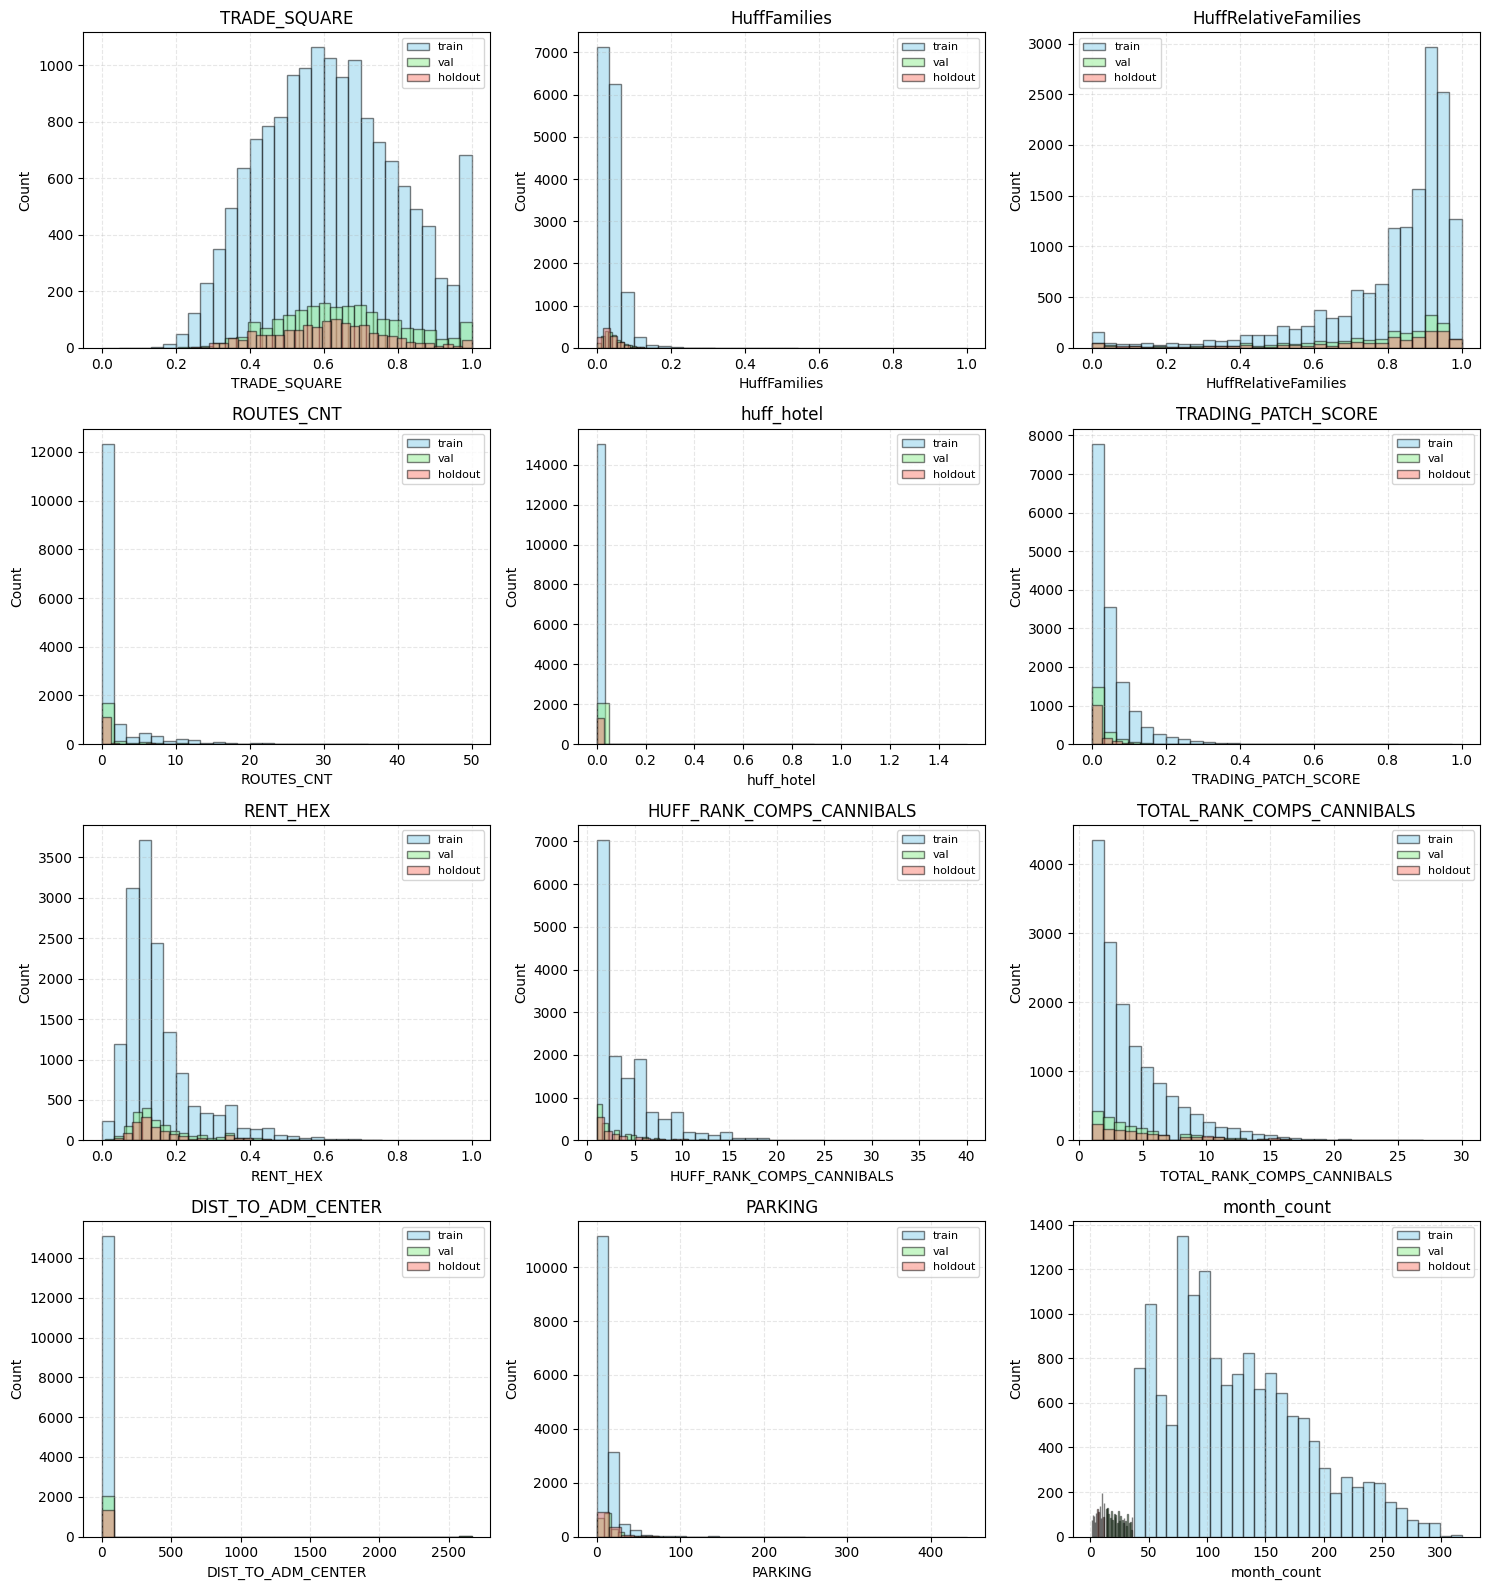

In [32]:
num_cols = numeric
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_train[col].dropna(), bins=30, color='skyblue', alpha=0.5, label='train', edgecolor='black')
    plt.hist(df_val[col].dropna(), bins=30, color='lightgreen', alpha=0.5, label='val', edgecolor='black')
    plt.hist(df_holdout[col].dropna(), bins=30, color='salmon', alpha=0.5, label='holdout', edgecolor='black')

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

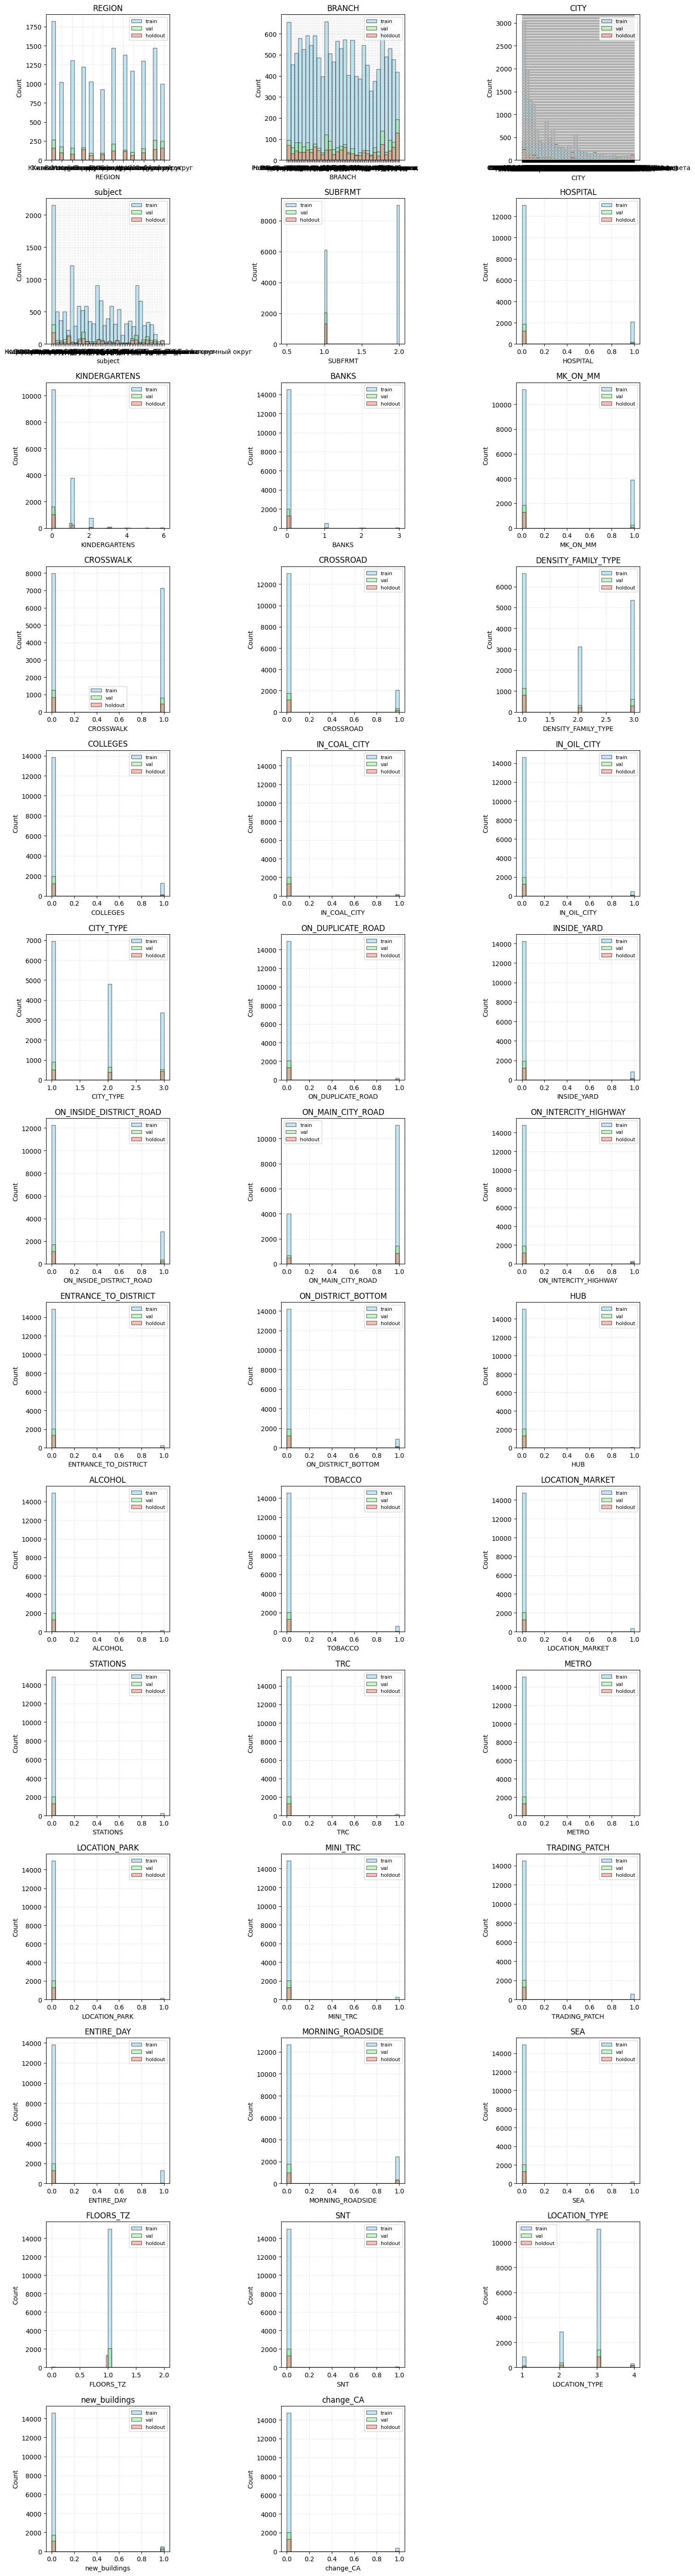

In [33]:
num_cols = categorical
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    # Строим гистограмму для каждого датасета на одном графике
    plt.hist(df_train[col].dropna(), bins=30, color='skyblue', alpha=0.5, label='train', edgecolor='black')
    plt.hist(df_val[col].dropna(), bins=30, color='lightgreen', alpha=0.5, label='val', edgecolor='black')
    plt.hist(df_holdout[col].dropna(), bins=30, color='salmon', alpha=0.5, label='holdout', edgecolor='black')

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

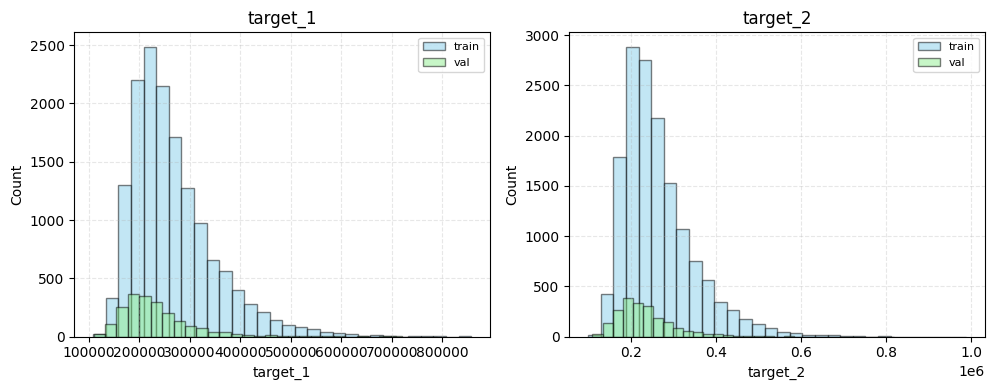

In [34]:
num_cols = target
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_train[col].dropna(), bins=30, color='skyblue', alpha=0.5, label='train', edgecolor='black')
    plt.hist(df_val[col].dropna(), bins=30, color='lightgreen', alpha=0.5, label='val', edgecolor='black')

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

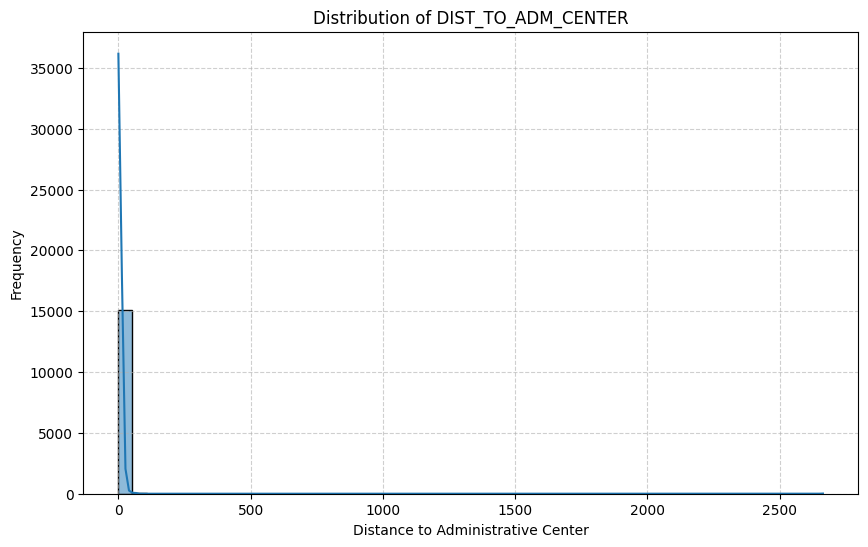

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_train['DIST_TO_ADM_CENTER'], bins=50, kde=True)
plt.title('Distribution of DIST_TO_ADM_CENTER')
plt.xlabel('Distance to Administrative Center')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [36]:
city_counts1 = df_train['CITY'].value_counts()
city_counts2 = df_val['CITY'].value_counts()

combined_city_counts = city_counts1.add(city_counts2, fill_value=0)

df_train['is_only_one_in_city'] = df_train['CITY'].map(combined_city_counts).eq(1).astype(int)
df_val['is_only_one_in_city'] = df_val['CITY'].map(combined_city_counts).eq(1).astype(int)
df_holdout['is_only_one_in_city'] = df_holdout['CITY'].map(combined_city_counts).eq(1).astype(int)

In [37]:
df_train

,ID,REGION,BRANCH,CITY,subject,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,KINDERGARTENS,BANKS,MK_ON_MM,ROUTES_CNT,CROSSWALK,CROSSROAD,DENSITY_FAMILY_TYPE,COLLEGES,huff_hotel,TRADING_PATCH_SCORE,RENT_HEX,IN_COAL_CITY,IN_OIL_CITY,CITY_TYPE,ON_DUPLICATE_ROAD,HUFF_RANK_COMPS_CANNIBALS,TOTAL_RANK_COMPS_CANNIBALS,INSIDE_YARD,ON_INSIDE_DISTRICT_ROAD,ON_MAIN_CITY_ROAD,ON_INTERCITY_HIGHWAY,ENTRANCE_TO_DISTRICT,ON_DISTRICT_BOTTOM,HUB,ALCOHOL,TOBACCO,LOCATION_MARKET,STATIONS,TRC,METRO,LOCATION_PARK,MINI_TRC,TRADING_PATCH,ENTIRE_DAY,MORNING_ROADSIDE,SEA,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2,is_only_one_in_city
0,1,Южный округ,Армавир,Кропоткин,Краснодарский край,2,0.445648,0.019780,0.83,0,0,0,0,5,1,0,1,0,0.000000,0.037696,0.100911,0,0,2,0,2,2,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,0.550733,0,318,0,0,175198.181281,174259.925193,0
1,2,Южный округ,Новороссийск Запад,Анапа,Краснодарский край,2,0.780890,0.060494,0.83,0,0,0,0,0,1,0,3,0,0.063891,0.031414,0.229610,0,0,2,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,1.114666,0,317,0,0,360629.424460,296286.063051,0
2,3,Южный округ,Ростов-на-Дону Запад,Таганрог,Ростовская область,2,0.471618,0.033680,0.84,0,0,0,1,0,1,0,1,0,0.000000,0.116230,0.128164,0,0,1,0,2,3,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,2,3.730973,10,315,0,0,252109.534031,250903.579740,0
3,4,Кавказский округ,Волгоград Восток,Камышин,Волгоградская область,2,0.555293,0.062644,0.76,0,1,0,0,0,1,0,2,0,0.000000,0.045026,0.105460,0,0,2,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,3,1.039118,15,314,0,0,362653.018943,351612.980992,0
4,5,Южный округ,Волгодонск,Волгодонск,Ростовская область,2,0.622970,0.030358,0.93,1,0,1,0,0,1,0,3,0,0.000000,0.141361,0.112611,0,0,2,0,7,4,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,2,1.595111,0,314,0,0,295733.315193,287970.899275,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15104,15105,Сибирский округ,Красноярск,Красноярск,Красноярский край,1,0.419759,0.103733,0.64,0,0,0,0,0,0,0,3,0,0.000000,0.000000,0.123746,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,11.306402,0,37,1,0,335833.035709,335285.135791,0
15105,15106,Уральский округ,Ноябрьск,Правохеттинский,Ямало-Ненецкий автономный округ,1,0.523817,0.015207,0.48,0,0,0,0,0,0,0,1,0,0.000000,0.014660,0.257512,0,0,3,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,0.251115,10,37,0,0,239449.710720,245862.395965,1
15106,15107,Южный округ,Волгодонск,Синегорский,Ростовская область,1,0.426907,0.075626,0.54,0,0,0,0,0,0,0,1,0,0.000000,0.010471,0.066066,0,0,3,0,1,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,1.170235,6,37,0,0,229265.834248,223720.175478,1
15107,15108,Южный округ,Ростов-на-Дону Запад,Ростов-на-Дону,Ростовская область,1,0.807060,0.041533,0.93,0,0,0,0,0,0,0,3,1,0.000000,0.086911,0.202879,0,0,1,0,7,7,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,3,6.246047,30,37,0,0,279075.187488,278484.672897,0


Calculating Mutual Information... (this may take a minute)


/var/folders/5w/td1qssr102g_shnry7z0q4k00000gn/T/ipykernel_34634/74459100.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_results, x='mi_score', y='feature', palette='viridis')


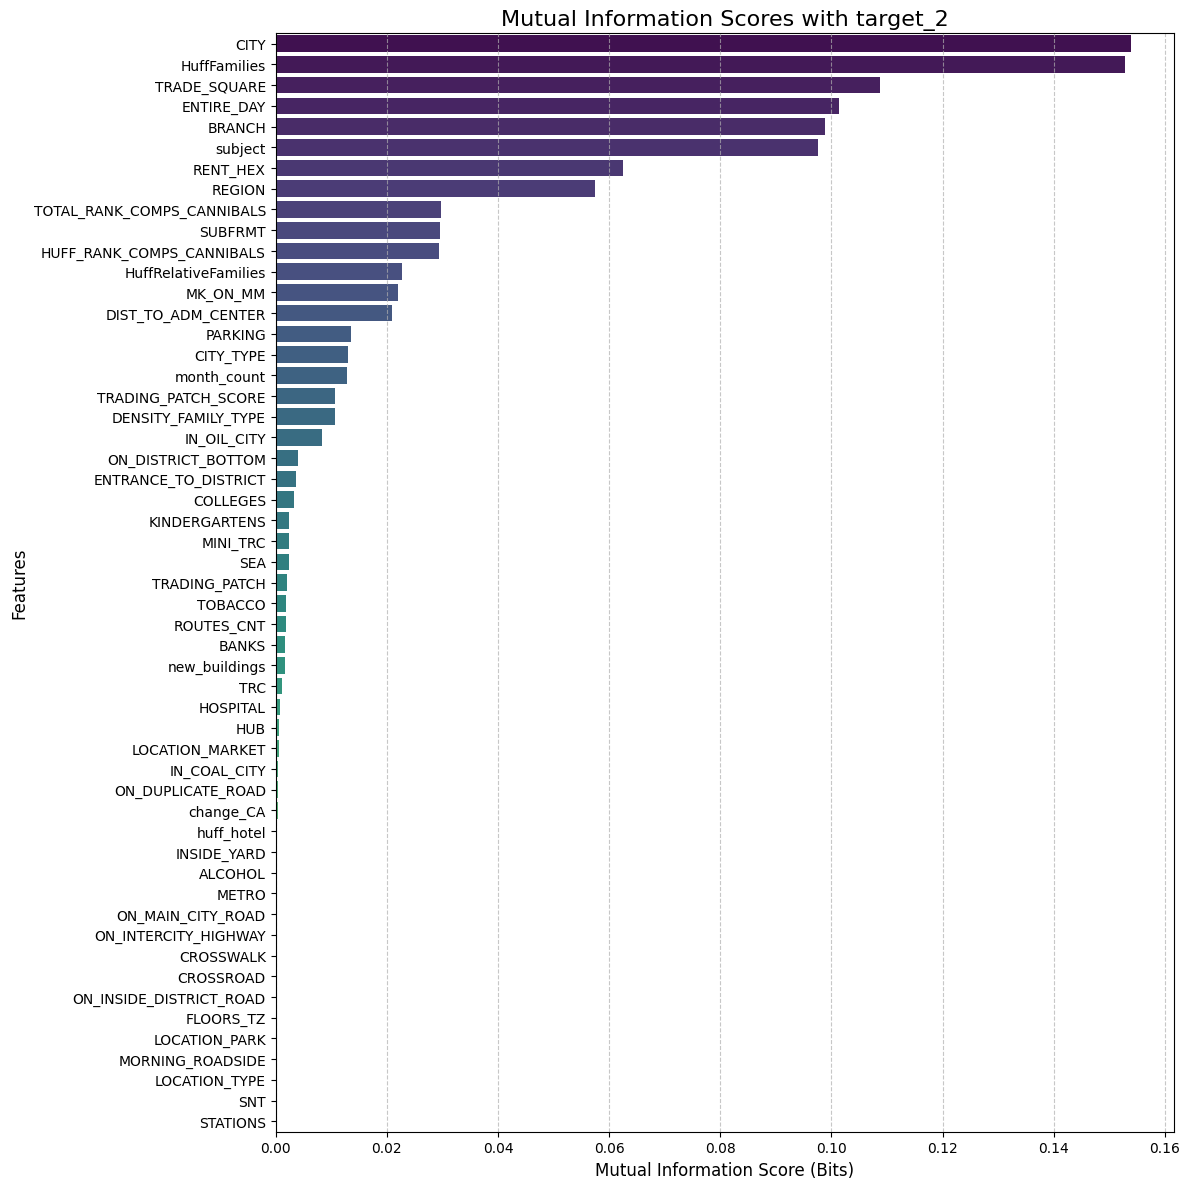


Top 10 features by Mutual Information:
                       feature  mi_score
2                         CITY  0.153903
42                HuffFamilies  0.152780
41                TRADE_SQUARE  0.108714
33                  ENTIRE_DAY  0.101436
1                       BRANCH  0.098866
3                      subject  0.097565
47                    RENT_HEX  0.062456
0                       REGION  0.057539
49  TOTAL_RANK_COMPS_CANNIBALS  0.029821
4                      SUBFRMT  0.029530


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# 1. Подготовка данных
df_mi = df_train.copy()
# Очищаем названия колонок от пробелов (на всякий случай)
df_mi.columns = df_mi.columns.str.strip()

# Убираем строки с пропусками в таргете, если они есть
target_col = 'target_2'
df_mi = df_mi.dropna(subset=[target_col])

# Список всех фичей
all_features = categorical + numeric
X = df_mi[all_features].copy()
y = df_mi[target_col]

# 2. Кодирование категориальных признаков
# Mutual Info требует числа на вход, даже для категорий
label_encoders = {}
for col in categorical:
    le = LabelEncoder()
    # Заполняем пропуски строкой 'None' перед кодированием
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Заполняем пропуски в числовых признаках медианой
X[numeric] = X[numeric].fillna(X[numeric].median())

# 3. Создание маски дискретных признаков
# Это критично для точности MI: True для категорий, False для непрерывных чисел
discrete_mask = [col in categorical for col in all_features]

# 4. Расчет Взаимной Информации
print("Calculating Mutual Information... (this may take a minute)")
mi_scores = mutual_info_regression(X, y, discrete_features=discrete_mask, random_state=42)

# 5. Визуализация
mi_results = pd.DataFrame({'feature': all_features, 'mi_score': mi_scores})
mi_results = mi_results.sort_values(by='mi_score', ascending=False)

plt.figure(figsize=(12, 12))
sns.barplot(data=mi_results, x='mi_score', y='feature', palette='viridis')
plt.title(f'Mutual Information Scores with {target_col}', fontsize=16)
plt.xlabel('Mutual Information Score (Bits)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Вывод топ-10 признаков
print("\nTop 10 features by Mutual Information:")
print(mi_results.head(10))